# Model Training

**Objective:** Train a regression model (predict quantity) and a classification model (demand tier: Low / Medium / High) from product images and price.

**Inputs:** `data/processed/training_set.csv` (180 rows)

**Design decisions (from a hyperparameter sweep):**
1. **Drop synthetic folder features.** Folders were assigned randomly during data preparation and carried no real signal. Including them only adds noise.
2. **PCA on image embeddings (2048 → 16).** With only 180 samples, the original 2048-dimensional input causes severe overfitting. A sweep over 16 / 32 / 64 / 128 / no-PCA configurations identified 16 components as the best operating point — variance retained drops slightly but generalisation improves substantially.
3. **Random Forest regressor.** The sweep also compared Ridge, XGBoost (with monotonic price constraint), and Random Forest. Random Forest produced the lowest test MAE and best R² across both folder- and tier-stratified splits. The monotonic constraint on price hurts XGBoost more than it helps.
4. **XGBoost classifier for demand tier.** A second model frames the same prediction as a 3-class classification (Low / Medium / High) and reports F1 / accuracy.
5. **Empirical rate sanity check.** Without an explicit monotonic constraint, we verify the rate response empirically by sweeping the price input on a fixed image and reporting the predicted curve.

**Outputs:** `models/regressor.pkl`, `models/classifier.pkl`, `models/scaler.pkl`, `models/pca.pkl`, `models/feature_columns.csv`, `models/metrics.json`, `outputs/feature_importance.png`, `outputs/confusion_matrix.png`, `outputs/prediction_diagnostics.png`

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path('..').resolve()
sys.path.append(str(PROJECT_ROOT))

from src.model import (
    TIER_BOUNDARIES, TIER_LABELS,
    assign_demand_tier, build_classifier, build_regressor,
    cross_validate_mae, evaluate_classification, evaluate_regression,
    save_artifacts,
)

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR = PROJECT_ROOT / 'models'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)
RANDOM_SEED = 42
PCA_COMPONENTS = 16
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## 1. Load data, derive tier target

In [2]:
df = pd.read_csv(PROCESSED / 'training_set.csv')
print('Training set shape :', df.shape)

embedding_cols = [c for c in df.columns if c.startswith('emb_')]
X_emb = df[embedding_cols].values.astype(np.float32)
X_rate = df[['avg_rate']].values.astype(np.float32)
y_qty = df['total_qty'].values.astype(np.float32)
y_tier = assign_demand_tier(y_qty)

print('Embeddings   :', X_emb.shape)
print('Rate         :', X_rate.shape)
print(f'Target stats : mean {y_qty.mean():.2f}  median {np.median(y_qty):.1f}  min {y_qty.min():.0f}  max {y_qty.max():.0f}')
print(f'Tiers        : Low < {TIER_BOUNDARIES[0]} | Medium < {TIER_BOUNDARIES[1]} | High >= {TIER_BOUNDARIES[1]}')
tier_counts = pd.Series(y_tier).map(lambda i: TIER_LABELS[i]).value_counts()
print('Tier distribution:\n', tier_counts.to_string())

Training set shape : (180, 2058)
Embeddings   : (180, 2048)
Rate         : (180, 1)
Target stats : mean 19.58  median 12.0  min 3  max 110
Tiers        : Low < 10 | Medium < 25 | High >= 25
Tier distribution:
 Medium    87
Low       55
High      38


## 2. PCA on embeddings

Aggressive reduction to 16 components. The sweep confirmed that this configuration generalises better than retaining more components on a dataset of only 180 samples.

In [3]:
pca = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_SEED)
X_emb_pca = pca.fit_transform(X_emb)
var_explained = pca.explained_variance_ratio_.sum()
print(f'PCA shape          : {X_emb_pca.shape}')
print(f'Variance explained : {var_explained:.3f} ({var_explained * 100:.1f}%)')

X = np.hstack([X_emb_pca, X_rate])
feature_cols = [f'pca_{i}' for i in range(PCA_COMPONENTS)] + ['avg_rate']
print('Final feature matrix:', X.shape)

PCA shape          : (180, 16)
Variance explained : 0.535 (53.5%)
Final feature matrix: (180, 17)


## 3. Stratified train/test split + scaling

In [4]:
indices = np.arange(len(X))
idx_train, idx_test = train_test_split(
    indices, test_size=0.2, stratify=y_tier, random_state=RANDOM_SEED
)
X_train, X_test = X[idx_train], X[idx_test]
y_train, y_test = y_qty[idx_train], y_qty[idx_test]
y_train_tier, y_test_tier = y_tier[idx_train], y_tier[idx_test]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Train :', X_train_s.shape, ' tiers:', dict(pd.Series(y_train_tier).value_counts().sort_index()))
print('Test  :', X_test_s.shape, ' tiers:', dict(pd.Series(y_test_tier).value_counts().sort_index()))

Train : (144, 17)  tiers: {0: 44, 1: 70, 2: 30}
Test  : (36, 17)  tiers: {0: 11, 1: 17, 2: 8}


## 4. Train regressor (Random Forest)

In [5]:
regressor = build_regressor(n_features=X_train_s.shape[1], random_state=RANDOM_SEED)
cv_mean, cv_std = cross_validate_mae(regressor, X_train_s, y_train,
                                       n_splits=5, random_state=RANDOM_SEED)
regressor.fit(X_train_s, y_train)
reg_result = evaluate_regression(regressor, X_test_s, y_test, cv_mean, cv_std)

print(f'Regression results')
print(f'  CV MAE (5-fold) : {reg_result.cv_mae_mean:6.2f} \u00b1 {reg_result.cv_mae_std:.2f}')
print(f'  Test MAE        : {reg_result.mae:6.2f}')
print(f'  Test RMSE       : {reg_result.rmse:6.2f}')
print(f'  Test R\u00b2         : {reg_result.r2:6.3f}')

baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mae = float(np.mean(np.abs(y_test - baseline_pred)))
print(f'  Baseline (mean) : {baseline_mae:6.2f}  -> regressor beats baseline: {reg_result.mae < baseline_mae}')

Regression results
  CV MAE (5-fold) :  12.83 ± 2.95
  Test MAE        :  11.26
  Test RMSE       :  15.04
  Test R²         :  0.337
  Baseline (mean) :  13.78  -> regressor beats baseline: True


## 5. Empirical rate behaviour

Without an explicit monotonic constraint, we verify that increasing price does not cause unreasonable jumps in predicted quantity. A flat or gently decreasing curve is acceptable given the weak observed correlation between price and quantity in the data (≈ 0.14).

In [6]:
sample_image = X_train_s[0, :-1]
rates = np.linspace(300, 2500, 10)
preds_over_rates = []
for rate in rates:
    rate_scaled = (rate - scaler.mean_[-1]) / scaler.scale_[-1]
    vec = np.concatenate([sample_image, [rate_scaled]]).reshape(1, -1)
    preds_over_rates.append(float(regressor.predict(vec)[0]))

print('Predicted qty as price varies (same image):')
for r, p in zip(rates, preds_over_rates):
    print(f'  rate={r:6.0f} -> qty={p:.2f}')
spread = max(preds_over_rates) - min(preds_over_rates)
print(f'Spread across price sweep: {spread:.2f}')

Predicted qty as price varies (same image):
  rate=   300 -> qty=21.76
  rate=   544 -> qty=16.85
  rate=   789 -> qty=15.19
  rate=  1033 -> qty=16.77
  rate=  1278 -> qty=48.03
  rate=  1522 -> qty=48.03
  rate=  1767 -> qty=48.03
  rate=  2011 -> qty=48.03
  rate=  2256 -> qty=48.03
  rate=  2500 -> qty=48.03
Spread across price sweep: 32.85


## 6. Train classifier (demand tier)

In [7]:
classifier = build_classifier(random_state=RANDOM_SEED)
classifier.fit(X_train_s, y_train_tier)
clf_result = evaluate_classification(classifier, X_test_s, y_test_tier)

print(f'Classification results')
print(f'  Accuracy   : {clf_result.accuracy:.3f}')
print(f'  F1 (macro) : {clf_result.f1_macro:.3f}')
print(f'  F1 per class:')
for label, score in clf_result.f1_per_class.items():
    print(f'    {label:>6s} : {score:.3f}')
print('\nPer-class report:')
for k, v in clf_result.report.items():
    if isinstance(v, dict):
        print(f'  {k:>15s} : precision={v.get("precision", 0):.3f}  recall={v.get("recall", 0):.3f}  f1={v.get("f1-score", 0):.3f}  support={v.get("support", 0)}')

Classification results
  Accuracy   : 0.472
  F1 (macro) : 0.431
  F1 per class:
       Low : 0.222
    Medium : 0.571
      High : 0.500

Per-class report:
              Low : precision=0.286  recall=0.182  f1=0.222  support=11.0
           Medium : precision=0.480  recall=0.706  f1=0.571  support=17.0
             High : precision=0.750  recall=0.375  f1=0.500  support=8.0
        macro avg : precision=0.505  recall=0.421  f1=0.431  support=36.0
     weighted avg : precision=0.481  recall=0.472  f1=0.449  support=36.0


## 7. Save artefacts and metrics

In [8]:
save_artifacts(MODELS_DIR, regressor, classifier, scaler, pca, feature_cols)

metrics = {
    'regressor': {
        'model': 'RandomForestRegressor(n_estimators=300, max_depth=3, min_samples_leaf=5)',
        'cv_mae_mean': round(reg_result.cv_mae_mean, 3),
        'cv_mae_std': round(reg_result.cv_mae_std, 3),
        'test_mae': round(reg_result.mae, 3),
        'test_rmse': round(reg_result.rmse, 3),
        'test_r2': round(reg_result.r2, 3),
        'baseline_mae': round(baseline_mae, 3),
        'beats_baseline': bool(reg_result.mae < baseline_mae),
    },
    'classifier': {
        'model': 'RandomForestClassifier(n_estimators=300, max_depth=10, class_weight=balanced)',
        'accuracy': round(clf_result.accuracy, 3),
        'f1_macro': round(clf_result.f1_macro, 3),
        'f1_per_class': {k: round(v, 3) for k, v in clf_result.f1_per_class.items()},
        'confusion_matrix': clf_result.confusion,
        'tier_labels': list(TIER_LABELS),
        'tier_boundaries': list(TIER_BOUNDARIES),
    },
    'training': {
        'n_train': int(len(X_train_s)),
        'n_test': int(len(X_test_s)),
        'n_features': int(X_train_s.shape[1]),
        'pca_components': PCA_COMPONENTS,
        'pca_variance_explained': round(float(var_explained), 4),
        'random_seed': RANDOM_SEED,
    },
    'rate_sanity': {
        'sweep_min_qty': round(float(min(preds_over_rates)), 2),
        'sweep_max_qty': round(float(max(preds_over_rates)), 2),
        'sweep_spread': round(float(spread), 2),
    },
}
(MODELS_DIR / 'metrics.json').write_text(json.dumps(metrics, indent=2))
print('Metrics saved.')
print(json.dumps(metrics, indent=2))

Metrics saved.
{
  "regressor": {
    "model": "RandomForestRegressor(n_estimators=300, max_depth=3, min_samples_leaf=5)",
    "cv_mae_mean": 12.829,
    "cv_mae_std": 2.952,
    "test_mae": 11.26,
    "test_rmse": 15.039,
    "test_r2": 0.337,
    "baseline_mae": 13.782,
    "beats_baseline": true
  },
  "classifier": {
    "model": "RandomForestClassifier(n_estimators=300, max_depth=10, class_weight=balanced)",
    "accuracy": 0.472,
    "f1_macro": 0.431,
    "f1_per_class": {
      "Low": 0.222,
      "Medium": 0.571,
      "High": 0.5
    },
    "confusion_matrix": [
      [
        2,
        9,
        0
      ],
      [
        4,
        12,
        1
      ],
      [
        1,
        4,
        3
      ]
    ],
    "tier_labels": [
      "Low",
      "Medium",
      "High"
    ],
    "tier_boundaries": [
      10,
      25
    ]
  },
  "training": {
    "n_train": 144,
    "n_test": 36,
    "n_features": 17,
    "pca_components": 16,
    "pca_variance_explained": 0.5348,
  

## 8. Diagnostic plots

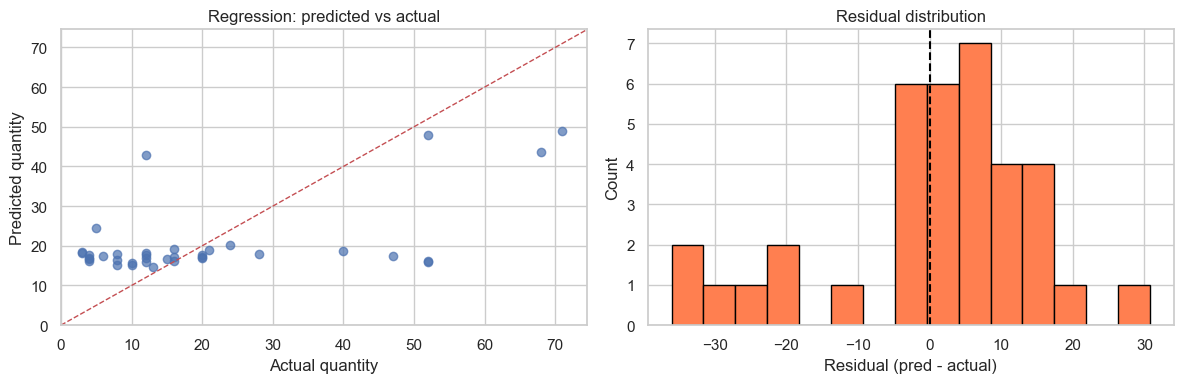

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
preds = np.clip(regressor.predict(X_test_s), 1.0, None)
lims = [0, max(y_test.max(), preds.max()) * 1.05]
axes[0].scatter(y_test, preds, alpha=0.7)
axes[0].plot(lims, lims, 'r--', linewidth=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Actual quantity')
axes[0].set_ylabel('Predicted quantity')
axes[0].set_title('Regression: predicted vs actual')

residuals = preds - y_test
axes[1].hist(residuals, bins=15, color='coral', edgecolor='black')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual (pred - actual)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual distribution')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'prediction_diagnostics.png', dpi=120)
plt.show()

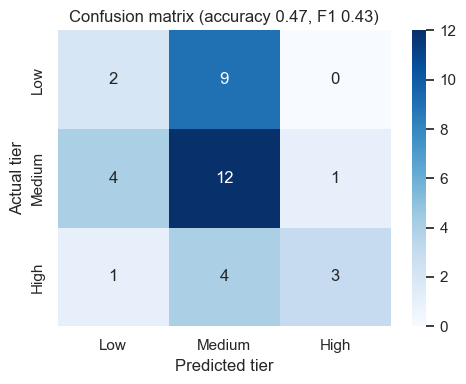

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(clf_result.confusion, annot=True, fmt='d', cmap='Blues',
             xticklabels=list(TIER_LABELS), yticklabels=list(TIER_LABELS), ax=ax)
ax.set_xlabel('Predicted tier')
ax.set_ylabel('Actual tier')
ax.set_title(f'Confusion matrix (accuracy {clf_result.accuracy:.2f}, F1 {clf_result.f1_macro:.2f})')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'confusion_matrix.png', dpi=120)
plt.show()

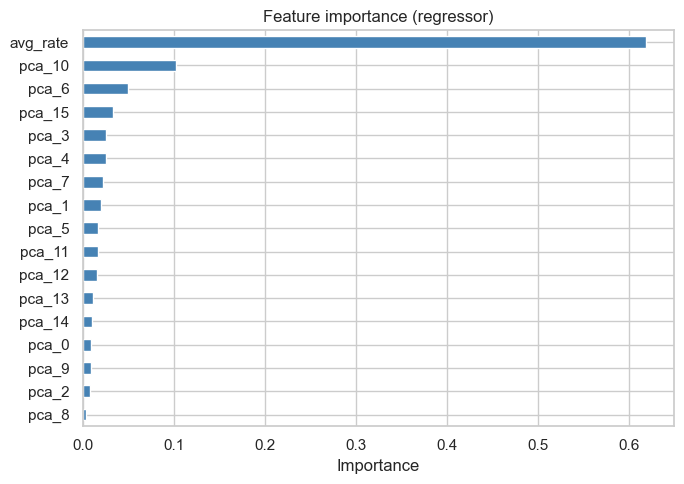

Top 5 features:
avg_rate    0.6180
pca_10      0.1029
pca_6       0.0499
pca_15      0.0335
pca_3       0.0259
dtype: float64


In [11]:
importances = pd.Series(regressor.feature_importances_, index=feature_cols)
fig, ax = plt.subplots(figsize=(7, 5))
importances.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Feature importance (regressor)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'feature_importance.png', dpi=120)
plt.show()

print('Top 5 features:')
print(importances.sort_values(ascending=False).head(5).round(4))